10Hz组 pac_z_score 维度: (2, 17, 8, 29, 3, 60, 39)
Sham组 pac_z_score 维度: (2, 18, 8, 29, 3, 60, 39)

原始索引数量：29 | 排除[0, 3, 4, 8, 13, 22]后候选索引数量：23
候选索引：[ 1  2  5  6  7  9 10 11 12 14 15 16 17 18 19 20 21 23 24 25 26 27 28]

开始200次随机实验：每次从候选索引中选6维...
第1次实验 | 选中索引：[np.int64(9), np.int64(10), np.int64(15), np.int64(18), np.int64(20), np.int64(28)] | 留一法准确率：0.7429
第2次实验 | 选中索引：[np.int64(2), np.int64(6), np.int64(10), np.int64(16), np.int64(24), np.int64(25)] | 留一法准确率：0.4571
第3次实验 | 选中索引：[np.int64(1), np.int64(2), np.int64(9), np.int64(16), np.int64(17), np.int64(18)] | 留一法准确率：0.6000
第4次实验 | 选中索引：[np.int64(5), np.int64(7), np.int64(14), np.int64(21), np.int64(26), np.int64(28)] | 留一法准确率：0.5714
第5次实验 | 选中索引：[np.int64(6), np.int64(9), np.int64(20), np.int64(21), np.int64(25), np.int64(27)] | 留一法准确率：0.3429
第6次实验 | 选中索引：[np.int64(10), np.int64(11), np.int64(14), np.int64(16), np.int64(17), np.int64(21)] | 留一法准确率：0.3714
第7次实验 | 选中索引：[np.int64(1), np.int64(11), np.int64(17), np.int64(18), np.int64(25)

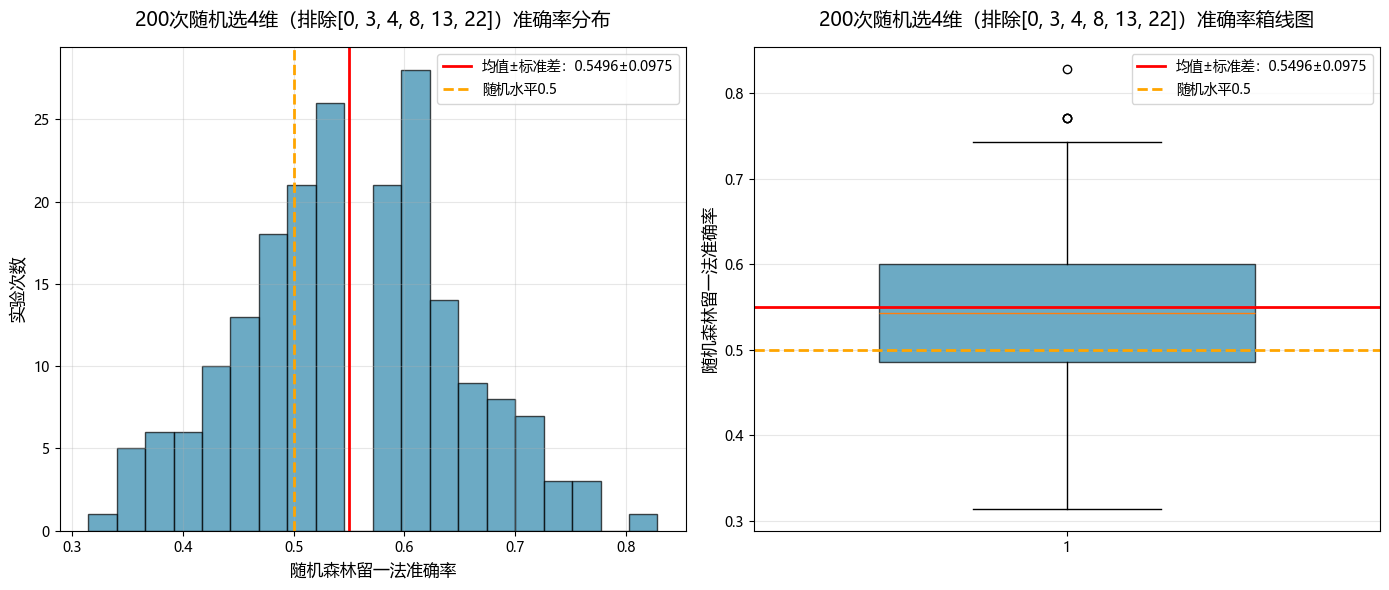

准确率分布图已保存至：D:\山东第一医科大学\结果\200次随机选6维_排除[0, 3, 4, 8, 13, 22]_准确率分布图.png


In [ ]:
import scipy.io as sio
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import os
import pandas as pd

# ===================== Global Settings (Adjust as needed) =====================
RANDOM_TIMES = 200  # Number of random experiments
SELECT_NUM = 5      # Select 6 features from 29
EXCLUDE_IDX = [0,4,8,13,22]  # Indices to exclude
# File paths
file_10hz = r'D:\山东第一医科大学\数据\Task\八因子\频段耦合\跨通道\pac\其他调制枕叶\10hz\10hz_pac_z_m_top_down.mat'
file_sham = r'D:\山东第一医科大学\数据\Task\八因子\频段耦合\跨通道\pac\其他调制枕叶\sham\sham_pac_z_m_top_down.mat'


# ===================== 1. Data Loading (Load once to avoid repeated I/O) =====================
def load_data():
    """Load 10Hz and Sham group data, return raw data"""
    data_10hz = sio.loadmat(file_10hz, squeeze_me=True)
    data_sham = sio.loadmat(file_sham, squeeze_me=True)
    print("10Hz group pac_z_score shape:", data_10hz['pac_z_score'].shape)
    print("Sham group pac_z_score shape:", data_sham['pac_z_score'].shape)
    return data_10hz['pac_z_score'], data_sham['pac_z_score']

# Load data once
data_10hz_raw, data_sham_raw = load_data()

# ===================== 2. Single Experiment Function (Input indices, return accuracy) =====================
def single_experiment(select_idx):
    """
    Single experiment: slice data by selected indices, run full pipeline, return LOOCV accuracy
    :param select_idx: Randomly selected 6 feature indices (np.array)
    :return: rf_loo_acc: Random Forest LOOCV accuracy for this experiment
    """
    # 2.1 Extract post-pre features (slice 29 dimensions by selected indices, excluded specified indices)
    pre_10hz = data_10hz_raw[0, :, :, select_idx, :, :, 15:24]
    post_10hz = data_10hz_raw[1, :, :, select_idx, :, :, 15:24]
    delta_10hz = post_10hz - pre_10hz
    delta_10hz = delta_10hz.transpose(1,2,0,3,4,5)

    # Sham group
    pre_sham = data_sham_raw[0, :, :, select_idx, :, :, 15:24]
    post_sham = data_sham_raw[1, :, :, select_idx, :, :, 15:24]
    delta_sham = post_sham - pre_sham
    delta_sham = delta_sham.transpose(1,2,0,3,4,5)

    # 2.2 Feature processing (Original aggregation: mean(axis=(1,2,3)))
    n_sub_10hz = delta_10hz.shape[0]
    n_sub_sham = delta_sham.shape[0]

    delta_10hz_agg = delta_10hz.mean(axis=(1,2,3))
    delta_sham_agg = delta_sham.mean(axis=(1,2,3))

    feat_10hz = delta_10hz_agg.reshape(n_sub_10hz, -1)
    feat_sham = delta_sham_agg.reshape(n_sub_sham, -1)

    # 2.3 Concatenate features and labels
    X = np.vstack([feat_10hz, feat_sham])
    y = np.hstack([np.ones(feat_10hz.shape[0]), np.zeros(feat_sham.shape[0])])

    # 2.4 Standardization + PCA (Retain 95% variance)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # 2.5 Random Forest with Leave-One-Out Cross-Validation
    loo = LeaveOneOut()
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    y_true_loo = []
    y_proba_loo = []

    for train_idx, test_idx in loo.split(X_pca):
        X_train, X_test = X_pca[train_idx], X_pca[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        rf_model.fit(X_train, y_train)
        y_proba = rf_model.predict_proba(X_test)[:, 1]
        y_true_loo.append(y_test[0])
        y_proba_loo.append(y_proba[0])

    y_true_loo = np.array(y_true_loo)
    y_proba_loo = np.array(y_proba_loo)
    rf_loo_acc = accuracy_score(y_true_loo, (y_proba_loo >= 0.5).astype(int))

    return rf_loo_acc

# ===================== 3. Main Loop for 200 Random Experiments =====================
# Create candidate indices after excluding specified indices
all_29_idx = np.arange(29)  # Original 0-28 indices
candidate_idx = all_29_idx[~np.isin(all_29_idx, EXCLUDE_IDX)]  # Candidate set after exclusion
print(f"\nOriginal indices: 29 | Candidates after excluding {EXCLUDE_IDX}: {len(candidate_idx)}")
print(f"Candidate indices: {candidate_idx}")

print(f"\nStarting {RANDOM_TIMES} random experiments: Select {SELECT_NUM} dimensions from candidates each time...")
# Result storage
all_results = []  # Each element: [selected indices (string), accuracy]
acc_list = []     # Only store accuracies for statistics and plotting

for i in range(RANDOM_TIMES):
    # Randomly select 6 unique indices from candidates
    select_idx = np.random.choice(candidate_idx, size=SELECT_NUM, replace=False)
    select_idx_sorted = sorted(select_idx)  # Sort for readability
    # Run single experiment
    current_acc = single_experiment(select_idx)
    # Save results
    all_results.append([str(select_idx_sorted), current_acc])
    acc_list.append(current_acc)
    # Print progress
    
    print(f"Experiment {i+1} | Selected indices: {select_idx_sorted} | LOOCV Accuracy: {current_acc:.4f}")

# Convert to numpy array for statistics
acc_array = np.array(acc_list)

# ===================== 4. Result Statistics =====================
print(f"\n===================== Statistics of {RANDOM_TIMES} Experiments =====================")
print(f"Mean Accuracy: {np.mean(acc_array):.4f}")
print(f"Accuracy Std: {np.std(acc_array):.4f}")
print(f"Max Accuracy: {np.max(acc_array):.4f} (Experiment {np.argmax(acc_array)+1})")
print(f"Min Accuracy: {np.min(acc_array):.4f} (Experiment {np.argmin(acc_array)+1})")
print(f"Median Accuracy: {np.median(acc_array):.4f}")
print(f"Experiments with Accuracy > 0.5: {np.sum(acc_array>0.5)} ({np.sum(acc_array>0.5)/RANDOM_TIMES*100:.2f}%)")

# ===================== 5. Save Results (CSV) =====================
df_results = pd.DataFrame(all_results, columns=['Selected Candidate Indices (6)', 'RF LOOCV Accuracy'])
df_results['Experiment'] = range(1, RANDOM_TIMES+1)
df_results = df_results[['Experiment', 'Selected Candidate Indices (6)', 'RF LOOCV Accuracy']]  # Reorder columns
csv_path = os.path.join(save_dir, f'{RANDOM_TIMES}random_exp_{SELECT_NUM}dims_exclude{EXCLUDE_IDX}_results.csv')
df_results.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\nResults saved to: {csv_path}")

# ===================== 6. Result Visualization (Accuracy Distribution + Boxplot) =====================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
acc_mean = np.mean(acc_array)
acc_std = np.std(acc_array)

# 6.1 Histogram: Accuracy distribution
ax1.hist(acc_array, bins=20, color='#2E86AB', alpha=0.7, edgecolor='black')
ax1.axvline(acc_mean, color='red', linewidth=2, label=f'Mean±Std: {acc_mean:.4f}±{acc_std:.4f}')
ax1.axvline(0.5, color='orange', linewidth=2, linestyle='--', label='Chance Level 0.5')
ax1.set_xlabel('RF LOOCV Accuracy', fontsize=12)
ax1.set_ylabel('Number of Experiments', fontsize=12)
ax1.set_title(f'{RANDOM_TIMES} Random Experiments ({SELECT_NUM}D, Exclude {EXCLUDE_IDX})', fontsize=14, pad=15)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 6.2 Boxplot: Accuracy variation
box_plot = ax2.boxplot(acc_array, patch_artist=True, widths=0.6)
box_plot['boxes'][0].set_facecolor('#2E86AB')
box_plot['boxes'][0].set_alpha(0.7)
ax2.axhline(acc_mean, color='red', linewidth=2, label=f'Mean±Std: {acc_mean:.4f}±{acc_std:.4f}')
ax2.axhline(0.5, color='orange', linewidth=2, linestyle='--', label='Chance Level 0.5')
ax2.set_ylabel('RF LOOCV Accuracy', fontsize=12)
ax2.set_title(f'{RANDOM_TIMES} Random Experiments ({SELECT_NUM}D, Exclude {EXCLUDE_IDX})', fontsize=14, pad=15)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='y')

# Save plot
plt.tight_layout()
plot_path = os.path.join(save_dir, f'{RANDOM_TIMES}random_exp_{SELECT_NUM}dims_exclude{EXCLUDE_IDX}_accuracy_dist.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Accuracy plot saved to: {plot_path}")

10Hz组 pac_z_score 维度: (2, 17, 8, 9, 9, 60, 39)
Sham组 pac_z_score 维度: (2, 18, 8, 9, 9, 60, 39)
10Hz组delta维度: (17, 8, 5, 3, 60, 9)
Sham组delta维度: (18, 8, 5, 3, 60, 9)
10Hz组被试数: 17, Sham组被试数: 18, 因子数: 8
单组特征维度: (17, 540)

合并后特征维度 (总样本数, 特征数): (35, 540)
10Hz组样本数: 17 Sham组样本数: 18

PCA降维后特征维度: (35, 9)
PCA保留的主成分数: 9
PCA累计解释方差比: 0.9566

===== 留一法交叉验证（随机森林） =====

===== 留一法统计结果（随机森林） =====
【默认阈值0.5】
  准确率: 0.6286 ± 0.4832
  灵敏度(Sensitivity): 0.5882 ± 0.4922
  特异度(Specificity): 0.6667 ± 0.4714
留一法AUC: 0.7304
【最优阈值0.630】
  准确率: 0.7429 ± 0.4371
  灵敏度(Sensitivity): 0.5294 ± 0.4991
  特异度(Specificity): 0.9444 ± 0.2291

===== 最优阈值0.630下详细结果 =====
混淆矩阵 ([[TN,FP],[FN,TP]]):
[[17  1]
 [ 8  9]]

分类报告（精确率/召回率/F1，召回率=灵敏度）:
              precision    recall  f1-score   support

   Sham组(负类)       0.68      0.94      0.79        18
   10Hz组(正类)       0.90      0.53      0.67        17

    accuracy                           0.74        35
   macro avg       0.79      0.74      0.73        35
weighted avg      

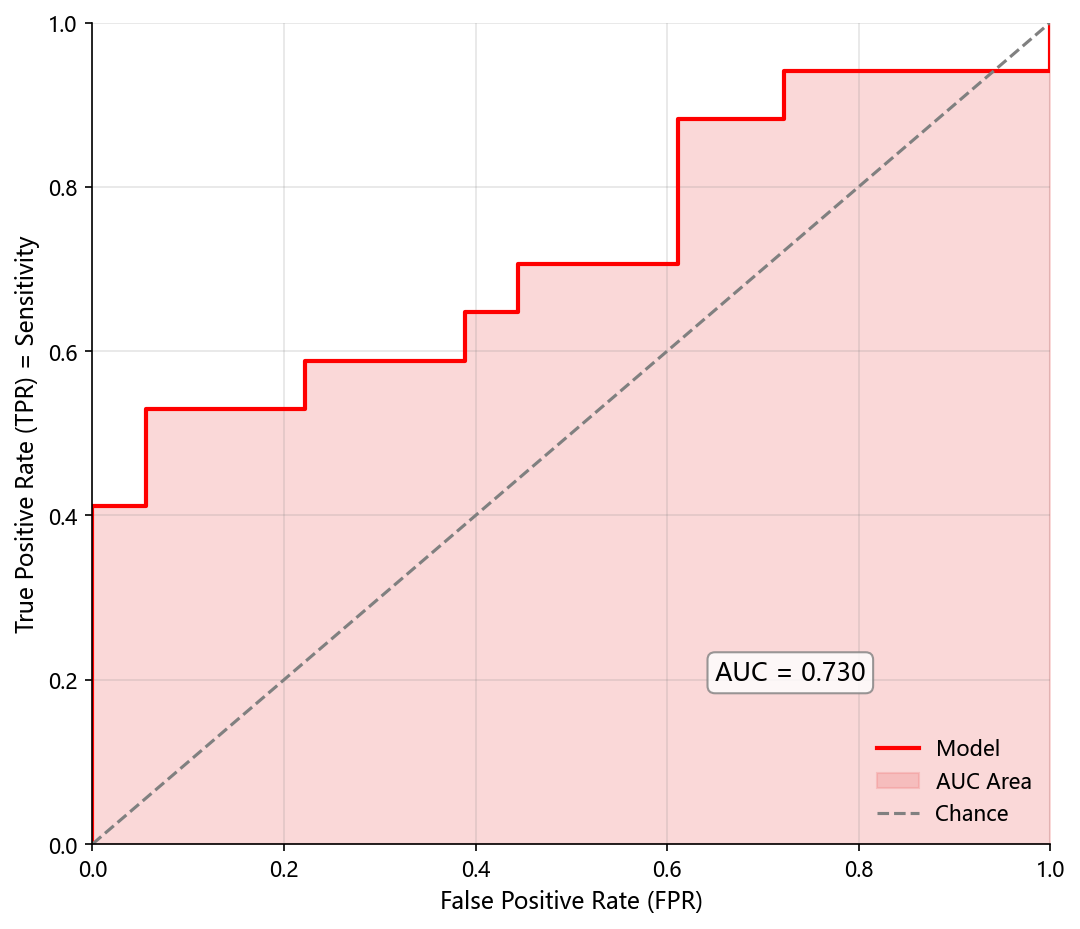

In [ ]:
import scipy.io as sio
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import os  

# ===================== Global Settings =====================
# Set font for plots to support Chinese characters and minus signs
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ===================== 1. Data Loading =====================
# Define file paths for both groups
file_10hz = r'D:\山东第一医科大学\数据\Task\八因子\频段耦合\跨通道\pac\10hz\10hz_pac_z_m.mat'
file_sham = r'D:\山东第一医科大学\数据\Task\八因子\频段耦合\跨通道\pac\sham\sham_pac_z_m.mat'

# Load MATLAB data files
data_10hz = sio.loadmat(file_10hz, squeeze_me=True)
data_sham = sio.loadmat(file_sham, squeeze_me=True)

# Print data dimensions for verification
print("10Hz group pac_z_score shape:", data_10hz['pac_z_score'].shape)
print("Sham group pac_z_score shape:", data_sham['pac_z_score'].shape)

# ===================== 2. Extract post-pre Features =====================
# Extract and compute difference for 10Hz group
pre_10hz = data_10hz['pac_z_score'][0, :, :, [0,2,3,4,5], 6:9, :, 15:24]  
post_10hz = data_10hz['pac_z_score'][1, :, :, [0,2,3,4,5], 6:9, :, 15:24]  
delta_10hz = post_10hz - pre_10hz  
delta_10hz = delta_10hz.transpose(1,2,0,3,4,5)

# Extract and compute difference for Sham group
pre_sham = data_sham['pac_z_score'][0, :, :, [0,2,3,4,5], 6:9, :, 15:24]  
post_sham = data_sham['pac_z_score'][1, :, :,[0,2,3,4,5], 6:9, :, 15:24]  
delta_sham = post_sham - pre_sham
delta_sham = delta_sham.transpose(1,2,0,3,4,5)

print("10Hz group delta shape:", delta_10hz.shape)
print("Sham group delta shape:", delta_sham.shape)

# ===================== 3. Feature Processing and Concatenation =====================
n_sub_10hz = delta_10hz.shape[0]  
n_sub_sham = delta_sham.shape[0]  
n_factors = delta_10hz.shape[1]   
print(f"10Hz subjects: {n_sub_10hz}, Sham subjects: {n_sub_sham}, Factors: {n_factors}")

# Feature aggregation: average over specified dimensions
delta_10hz_agg = delta_10hz.mean(axis=(1,2,3))  
delta_sham_agg = delta_sham.mean(axis=(1,2,3))

# Reshape to (subjects, features)
feat_10hz = delta_10hz_agg.reshape(n_sub_10hz , -1) 
feat_sham = delta_sham_agg.reshape(n_sub_sham, -1)  
print("Single group feature shape:", feat_10hz.shape)

# Combine features and create labels (1=10Hz, 0=Sham)
X = np.vstack([feat_10hz, feat_sham])  
y = np.hstack([np.ones(feat_10hz.shape[0]), np.zeros(feat_sham.shape[0])])

print("\nCombined feature shape (samples, features):", X.shape)
print("10Hz samples:", np.sum(y==1), "Sham samples:", np.sum(y==0))

# ===================== 4. Standardization + PCA Dimensionality Reduction =====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA retaining 95% variance
pca = PCA(n_components=0.95, random_state=47)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA reduced feature shape: {X_pca.shape}")
print(f"Number of principal components retained: {X_pca.shape[1]}")
print(f"Total explained variance ratio: {np.sum(pca.explained_variance_ratio_):.4f}")

# ===================== 5. Leave-One-Out Cross-Validation (LOOCV) =====================
print("\n===== Leave-One-Out Cross-Validation (Random Forest) =====")
loo = LeaveOneOut()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Store results for each fold
y_true_loo = []    
y_proba_loo = []   
y_pred_loo = []    

# LOOCV loop
for train_idx, test_idx in loo.split(X_pca):
    X_train, X_test = X_pca[train_idx], X_pca[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    rf_model.fit(X_train, y_train)
    y_proba = rf_model.predict_proba(X_test)[:, 1]  # Probability for positive class (10Hz)
    y_pred = 1 if y_proba >= 0.5 else 0              # Prediction at default threshold
    
    # Store results
    y_true_loo.append(y_test[0])
    y_proba_loo.append(y_proba[0])
    y_pred_loo.append(y_pred)

# Convert to numpy arrays
y_true_loo = np.array(y_true_loo)
y_proba_loo = np.array(y_proba_loo)
y_pred_loo = np.array(y_pred_loo)

# ===================== 6. Calculate Performance Metrics =====================
def calc_sens_spec(y_true, y_pred):
    """
    Calculate Sensitivity and Specificity
    Returns: sensitivity, specificity, per-subject correct flags for STD calculation
    """
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    sens = TP / (TP + FN) if (TP + FN) != 0 else 0.0
    spec = TN / (TN + FP) if (TN + FP) != 0 else 0.0
    
    # Per-subject correctness for STD calculation
    tp_correct = np.where(y_true==1, (y_pred==1).astype(float), np.nan)
    tn_correct = np.where(y_true==0, (y_pred==0).astype(float), np.nan)
    return sens, spec, tp_correct, tn_correct

# Metrics at DEFAULT threshold (0.5) with STD
rf_loo_acc_def = accuracy_score(y_true_loo, y_pred_loo)
rf_loo_sens_def, rf_loo_spec_def, tp_correct_def, tn_correct_def = calc_sens_spec(y_true_loo, y_pred_loo)

acc_correct_def = (y_pred_loo == y_true_loo).astype(float)
rf_loo_acc_std_def = np.std(acc_correct_def)
rf_loo_sens_std_def = np.std(tp_correct_def[~np.isnan(tp_correct_def)]) if np.sum(~np.isnan(tp_correct_def))>0 else 0.0
rf_loo_spec_std_def = np.std(tn_correct_def[~np.isnan(tn_correct_def)]) if np.sum(~np.isnan(tn_correct_def))>0 else 0.0

# Metrics at OPTIMAL threshold (Youden's J statistic)
rf_loo_auc = None
optimal_threshold = None
if len(np.unique(y_true_loo)) > 1:
    rf_loo_auc = roc_auc_score(y_true_loo, y_proba_loo)
    fpr, tpr, thresholds = roc_curve(y_true_loo, y_proba_loo)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    y_pred_opt = (y_proba_loo >= optimal_threshold).astype(int)
    
    # Optimal threshold metrics with STD
    rf_loo_acc_opt = accuracy_score(y_true_loo, y_pred_opt)
    rf_loo_sens_opt, rf_loo_spec_opt, tp_correct_opt, tn_correct_opt = calc_sens_spec(y_true_loo, y_pred_opt)
    
    acc_correct_opt = (y_pred_opt == y_true_loo).astype(float)
    rf_loo_acc_std_opt = np.std(acc_correct_opt)
    rf_loo_sens_std_opt = np.std(tp_correct_opt[~np.isnan(tp_correct_opt)]) if np.sum(~np.isnan(tp_correct_opt))>0 else 0.0
    rf_loo_spec_std_opt = np.std(tn_correct_opt[~np.isnan(tn_correct_opt)]) if np.sum(~np.isnan(tn_correct_opt))>0 else 0.0
else:
    rf_loo_acc_opt, rf_loo_acc_std_opt = 0.0, 0.0
    rf_loo_sens_opt, rf_loo_sens_std_opt = 0.0, 0.0
    rf_loo_spec_opt, rf_loo_spec_std_opt = 0.0, 0.0

# ===================== 7. Print Results =====================
print(f"\n===== LOOCV Results (Random Forest) =====")
print(f"[Default Threshold 0.5]")
print(f"  Accuracy:         {rf_loo_acc_def:.4f} ± {rf_loo_acc_std_def:.4f}")
print(f"  Sensitivity:      {rf_loo_sens_def:.4f} ± {rf_loo_sens_std_def:.4f}")
print(f"  Specificity:      {rf_loo_spec_def:.4f} ± {rf_loo_spec_std_def:.4f}")

if rf_loo_auc is not None:
    print(f"LOOCV AUC: {rf_loo_auc:.4f}")
    print(f"[Optimal Threshold {optimal_threshold:.3f}]")
    print(f"  Accuracy:         {rf_loo_acc_opt:.4f} ± {rf_loo_acc_std_opt:.4f}")
    print(f"  Sensitivity:      {rf_loo_sens_opt:.4f} ± {rf_loo_sens_std_opt:.4f}")
    print(f"  Specificity:      {rf_loo_spec_opt:.4f} ± {rf_loo_spec_std_opt:.4f}")
else:
    print("LOOCV AUC: Cannot compute (uniform class distribution)")

# Print detailed results
if rf_loo_auc is not None:
    print(f"\n===== Detailed Results at Optimal Threshold {optimal_threshold:.3f} =====")
    print("Confusion Matrix ([[TN,FP],[FN,TP]]):")
    print(confusion_matrix(y_true_loo, y_pred_opt))
    print("\nClassification Report:")
    print(classification_report(y_true_loo, y_pred_opt, target_names=['Sham', '10Hz']))

# ===================== 8. Plot ROC Curve =====================
if rf_loo_auc is not None:
    fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
    
    # Plot step-style ROC curve
    ax.step(fpr, tpr, where='post', color='red', linewidth=2, label='Model')
    ax.fill_between(fpr, tpr, step='post', color='lightcoral', alpha=0.3, label='AUC Area')
    ax.plot([0, 1], [0, 1], 'gray', linestyle='--', linewidth=1.5, label='Chance')
    
    # Axis settings
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
    ax.set_ylabel('True Positive Rate (TPR) = Sensitivity', fontsize=11)
    
    # AUC annotation
    ax.text(0.65, 0.2, f'AUC = {rf_loo_auc:.3f}', fontsize=12, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    
    # Legend and style
    ax.legend(loc='lower right', frameon=False, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='-', alpha=0.2, color='gray')
    
    plt.tight_layout(pad=0)
    plt.show()